# Web Scraping
---

## ¿Qué es el web scraping?

Es la técnica/proceso automatizado de extraer datos de sitios web y transformarlos en un formato estructurado, como CSV, JSON o una base de datos

## Usos

* Recopilación de datos para investigación
* Buscar ofertas laborales, productos, servicios, etc.
* Obtener las cotizaciones de las acciones para tomar mejores decisiones de inversión 
* Comparación de precios de vuelos, hoteles, etc.
* Generación de bases de datos
* Automatización de tareas
* Monitoreo de redes sociales

## ¿Es legal el web scraping?

La legalidad del web scraping depende de las condiciones de servicio del sitio web y de las leyes aplicables, como la normativa sobre derechos de autor y privacidad de datos

## ¿Qué es un archivo robots.txt y por qué es importante?

Un archivo robots.txt es un conjunto de instrucciones en un sitio web para informar a los rastreadores web sobre a qué partes del sitio pueden o no acceder

## ¿Qué herramientas son adecuadas para el scraping de sitios web estáticos?

Herramientas como BeautifulSoup o Requests son adecuadas para el scraping de pequeños proyectos, mientras que Scrapy y lxml son adecuadas para grandes proyectos con sitios web estáticos

## ¿Qué herramientas son adecuadas para el scraping de sitios web dinámicos?

Selenium, Scrapy, Puppeteer y Playwright son adecuados para raspar sitios web dinámicos

## Ejemplo

* Hacer un raspado o scraping de datos sobre la población del mundo
* Los datos estan disponibles en sitio de **Worldometers**
* ***Objetivo***: obtener esa tabla y convertirla en un **DataFrame** sin tener que copiar todos estos datos a mano 

In [14]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import plotly.express as px

In [2]:
url = "https://www.worldometers.info/world-population/population-by-country/"

In [3]:
res = requests.get(url)

In [4]:
res.status_code

200

In [5]:
# res.text

In [6]:
soup = BeautifulSoup(res.text)

In [7]:
data = soup.find_all("table")[0]

In [8]:
# data

In [9]:
df_population = pd.read_html(str(data))[0]

/var/folders/0n/g5l4v8c52nn4wxk7hl89vk3m0000gn/T/ipykernel_24717/1371522127.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_population = pd.read_html(str(data))[0]


In [10]:
df_population.head()

,#,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/KmÂ²),Land Area (KmÂ²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,India,1463865525,0.89%,12929734,492,2973190,"â495,753",1.94,28.8,37.1%,17.78%
1,2,China,1416096094,â0.23%,"â3,225,184",151,9388211,"â268,126",1.02,40.1,67.5%,17.20%
2,3,United States,347275807,0.54%,1849236,38,9147420,1230663,1.62,38.5,82.8%,4.22%
3,4,Indonesia,285721236,0.79%,2233305,158,1811570,"â39,509",2.10,30.4,59.6%,3.47%
4,5,Pakistan,255219554,1.57%,3950390,331,770880,"â1,235,336",3.50,20.6,34.4%,3.10%


In [11]:
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   #                        233 non-null    int64  
 1   Country (or dependency)  233 non-null    object 
 2   Population 2025          233 non-null    int64  
 3   Yearly Change            233 non-null    object 
 4   Net Change               233 non-null    object 
 5   Density (P/KmÂ²)         233 non-null    int64  
 6   Land Area (KmÂ²)         233 non-null    int64  
 7   Migrants (net)           233 non-null    object 
 8   Fert. Rate               233 non-null    float64
 9   Median Age               233 non-null    float64
 10  Urban Pop %              210 non-null    object 
 11  World Share              233 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 22.0+ KB


In [13]:
df_population['Population 2025']

0      1463865525
1      1416096094
2       347275807
3       285721236
4       255219554
          ...    
228          4359
229          3469
230          2608
231          1821
232           501
Name: Population 2025, Length: 233, dtype: int64

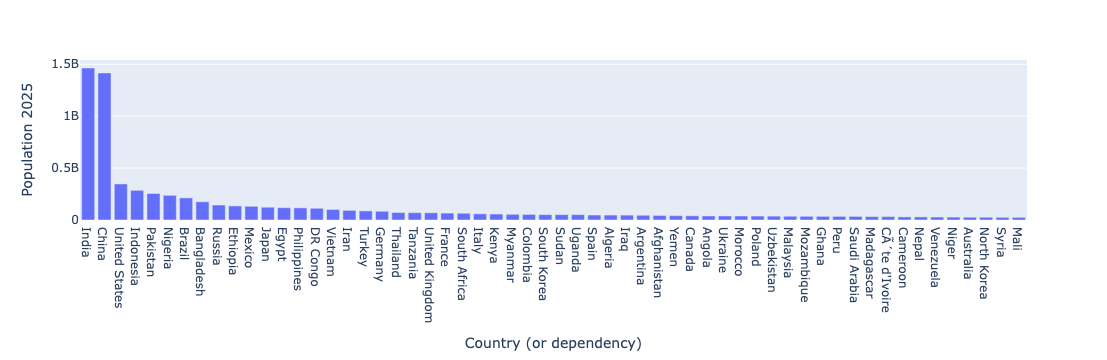

In [17]:
df_population_filter = df_population[df_population['Population 2025'] > 25000000]
fig = px.bar(df_population_filter, x = 'Country (or dependency)', y = 'Population 2025')
fig.show()